In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from src.preprocessing import process_store_data
from src.features import attach_store_data, make_features, make_targets
# NOTE: train_df['Open'] == 0 -> train_df['Sales'] = 0. This happens always
# TODO: Clusters on sales and/or holidays that occur together?


DATA_DIR = '../datasets/rossmann-store-sales'
STORE_FILE = os.path.join(DATA_DIR, 'store.csv')
TRAIN_FILE = os.path.join(DATA_DIR, 'train.csv')
TEST_FILE = os.path.join(DATA_DIR, 'test.csv')

FORECAST_HORIZON = 6*7 # We're forecasting daily for 6 weeks into the future
LAGS = [1, 2, 7, 30, 90, 182, 365]
DIFFS = [1, 30, 90, 182, 365]
ROLL_WINDOWS = { 7: 1, # window: lags
                30: [30, 90, 182, 365]}
HOLIDAY_WINDOWS = [-7, 0, 7]




In [2]:
df_train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'], dtype={'StateHoliday': str}).drop(['Customers'], axis=1)

In [3]:
store_df = pd.read_csv(STORE_FILE)
store_df = process_store_data(store_df)

df_train = pd.read_csv(TRAIN_FILE,
                       parse_dates=['Date'],
                       dtype={'StateHoliday': str} # 0 -> '0'
                       ).drop(['Customers'], axis=1)

df_train_store = attach_store_data(df_train, store_df)

# TODO: Predict log-transformed sales?
df_features = make_features(df_train_store, lags=LAGS, roll_windows=ROLL_WINDOWS, diffs=DIFFS, holiday_windows=HOLIDAY_WINDOWS)
#targets = make_targets(df=df_train[['Date', 'Store', 'Sales']], horizon=FORECAST_HORIZON)

#test_df = pd.read_csv(TEST_FILE, index_col=0, parse_dates=['Date'])
#test_df = features.attach_store_data(test_df, store_df)

In [9]:
df_features.shape

(1017209, 81)

In [4]:
sales_df = df_train[['Date', 'Store', 'Sales']]

In [ ]:
df_p = (pd.pivot(sales_df, index=sales_df.columns[0], columns=sales_df.columns[1], values=sales_df.columns[2])
            .sort_index())  # Sorted from oldest to newest

df_p.head()

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-02,5530.0,4422.0,6823.0,9941.0,4253.0,6089.0,8244.0,5419.0,4903.0,4812.0,...,5099.0,3955.0,6220.0,4576.0,4126.0,5097.0,10797.0,6218.0,20642.0,3697.0
2013-01-03,4327.0,4159.0,5902.0,8247.0,3465.0,5398.0,7231.0,4842.0,4602.0,4675.0,...,4330.0,3151.0,4779.0,3654.0,3508.0,4579.0,8716.0,5563.0,18463.0,4297.0
2013-01-04,4486.0,4484.0,6069.0,8290.0,4456.0,6092.0,7758.0,4059.0,4798.0,5114.0,...,3956.0,3990.0,5491.0,3596.0,3933.0,4640.0,9788.0,5524.0,18371.0,4540.0
2013-01-05,4997.0,2342.0,4523.0,10338.0,1590.0,3872.0,5218.0,2337.0,4254.0,4256.0,...,2624.0,5128.0,2113.0,2897.0,3156.0,3325.0,9513.0,5194.0,18856.0,4771.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-27,6102.0,6627.0,8107.0,11812.0,7059.0,5723.0,14869.0,8739.0,10649.0,7212.0,...,7042.0,11221.0,10717.0,8082.0,6761.0,7742.0,14383.0,7582.0,26720.0,10712.0
2015-07-28,5011.0,5671.0,8864.0,10275.0,6083.0,4839.0,12342.0,6717.0,8751.0,6140.0,...,6037.0,9533.0,8211.0,6478.0,5282.0,6793.0,9583.0,6468.0,25518.0,8093.0
2015-07-29,4782.0,6402.0,7610.0,10514.0,5899.0,5275.0,12074.0,7029.0,7776.0,5524.0,...,5536.0,8168.0,6302.0,6212.0,4600.0,4907.0,9179.0,6640.0,25840.0,7661.0


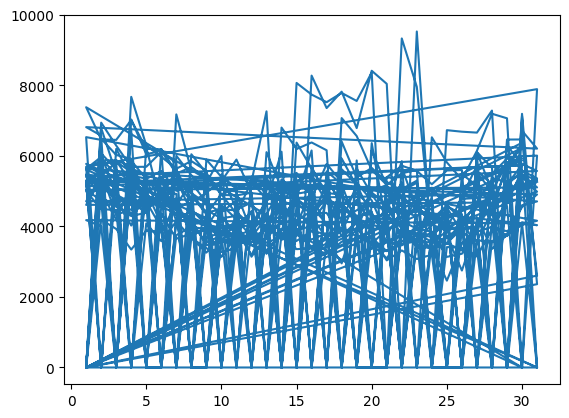

In [ ]:
import matplotlib.pyplot as plt

# Extract components
df_p["day_of_week"]   = df_p.index.dayofweek      # Monday=0, Sunday=6
df_p["day_of_month"]  = df_p.index.day
df_p["day_of_year"]   = df_p.index.dayofyear

# For day of quarter, compute relative to quarter start
df_p["day_of_quarter"] = (df_p.index - df_p.index.to_period("Q").start_time).days + 1

plt.plot(df_p["day_of_month"], df_p.iloc[:, 0])